# Imports

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, balanced_accuracy_score, f1_score, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
import pandas as pd
import seaborn as sn
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt


# Loading data

In [ ]:
!git clone https://git.wur.nl/manuel.cordovaneira/paperopenset2025_osnn.git data #used for paper

Cloning into 'data'...
remote: Enumerating objects: 16, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 16 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (16/16), 10.45 MiB | 6.77 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [ ]:
#extract features
!unzip 'data/features/resnet18.zip' -d 'data/features/'

Archive:  data/features/resnet18.zip
   creating: data/features/resnet18/
  inflating: data/features/resnet18/test.npy  
  inflating: data/features/resnet18/train.npy  
  inflating: data/features/resnet18/val.npy  


In [ ]:
#To put all features coming from a single or different extractors in one dictionary.
# This features are from a single split. The initial experiments used 3 splits with the majority classes as known
# See details on how to load data per split in Section 'Full pipeline for both methods'.
def initialize_data(feature_extractors, features_dir="data/features/"):
  full_data = {}
  for split in ['train', 'val', 'test']:
    full_data [split] = {'labels': None, 'features':{}}
    for feature_extractor in feature_extractors:
      data = np.load(features_dir + feature_extractor + "/" + split + ".npy")
      full_data [split]['labels'] = data[:,-2].astype(int) # species_index
      n_imgs, _ = data.shape
      names = np.empty([n_imgs, 1], dtype=object)
      for i in range(n_imgs):
        names[i] = str(data[i,-2]) + '_' + str(data[i,-1])
      full_data [split]['image_name'] = names# data[:,-2]+'_'+data[:,-1] # The last element correspond to the image_name
      full_data [split]['features'][feature_extractor] = data[:,:-2] #the remaining values are features

  return full_data

In the .npy file, each line contains: n features and the species_index (0-8)

Species: ['P. platessa', 'S. solea', 'S. rhombus', 'E. gurnardus', 'S. maximus', 'L. limanda', 'A. radiata', 'M. merlangus', 'S. canicula']


# Create partitions

In the original FDWE dataset, training, validation and test sets are already defined for a closed-set problem. We will split them to simulate an open-set setup.


In [ ]:
# features are in a dictionary, each feature extractor is an element/key of the dictionary containing the features
# instances/features belonging to the 'species_to_be_considered' are putting together by feature_extractor
def generate_split(features, labels, images, species_to_be_considered):
  mask_ids = np.zeros(len(labels))
  mask_ids = np.array(mask_ids, dtype='bool')

  for specie in species_to_be_considered:
    idxs = (labels == specie)
    mask_ids = np.logical_or(mask_ids,idxs)

  sub_labels = labels[mask_ids]
  sub_images = images[mask_ids]
  sub_features = {}

  for feature_extractor in features:
    sub_features[feature_extractor] = features[feature_extractor][mask_ids,:]

  return sub_features, sub_labels, sub_images

#concat dictionaries/features from different feature extractors
def concat_dict(data_dict1, data_dict2):
  data = data_dict1.copy()
  for key in data:
    data[key] = np.concatenate((data[key], data_dict2[key]))

  return data

# Assing the unknown label (999) to the unknown instances
def update_unknown_labels(labels, unknown_species, unknown_label=99):
  for specie in unknown_species:
    labels [labels == specie] = unknown_label

  return labels

In [ ]:
# receives all the extracted features from the train/val/test sets,
# splitting data according to the known species, unknown_val (used for optimize thresholds) and unknown test species
# Instances from train/val/test splits belonging to Unknown species will be put all together
# For example:
# If species '5' is considered as unknown in the validation set, then we put together all the instances belonging to species 5 from
# train, val, and test set into the validation set, given that they will be only used in the validation set.
#full_data has features and labels per split (train/val/test)

def create_splits_joiningUnknown(full_data, known_classes, unknown_val, unknown_test):
  X_train = full_data['train']['features']
  Y_train = np.copy(full_data['train']['labels'])
  images_train = np.copy(full_data['train']['image_name'])

  X_val = full_data['val']['features']
  Y_val = np.copy(full_data['val']['labels'])
  images_val = np.copy(full_data['val']['image_name'])

  X_test = full_data['test']['features']
  Y_test = np.copy(full_data['test']['labels'])
  images_test = np.copy(full_data['test']['image_name'])

  # Unknown instances from the training and test split will be used in the validation
  # In this case, those species are not used neither on the train nor in the test set. So,
  # Unknown instances from train and test sets will be put in the validation unknown set
  X_train_valunk, Y_train_valunk, images_train_valunk = generate_split(X_train, Y_train, images_train, unknown_val)
  X_test_valunk, Y_test_valunk, images_test_valunk = generate_split(X_test, Y_test, images_test, unknown_val)

  # unknown instances from the training and val split that will be used in the test set
  # Unknown instances from train and validation will be put in the test unknown set
  X_train_testunk, Y_train_testunk, images_train_testunk = generate_split(X_train, Y_train, images_train, unknown_test)
  X_val_testunk, Y_val_testunk, images_val_testunk = generate_split(X_val, Y_val, images_val, unknown_test)

  # X_train variable will have only instances from known species
  # get only the known instances from the original FDWE training set
  X_train, Y_train, images_train = generate_split(X_train, Y_train, images_train, known_classes)

  # Get the subset with the known instances and val_unknown instances from the original FDWE training set
  # Instances that will be used as part of the validation set: 1) known species, 2) unknown_val species
  X_val, Y_val, images_val = generate_split(X_val, Y_val, images_val, np.concatenate((known_classes,unknown_val)))

  # add the unknown_val species (known unknown) from the training and test set
  X_val = concat_dict(X_val,X_train_valunk)
  X_val = concat_dict(X_val,X_test_valunk)
  Y_val = np.concatenate((Y_val, Y_train_valunk))
  Y_val = np.concatenate((Y_val, Y_test_valunk))
  images_val = np.concatenate((images_val, images_train_valunk))
  images_val = np.concatenate((images_val, images_test_valunk))

  #Update the labels of the unknown species. by deafult 999 is used as label for the unknown species
  Y_val = update_unknown_labels(Y_val, unknown_val)

  #same process explained above, but in this case for the test set
  X_test, Y_test, images_test = generate_split(X_test, Y_test, images_test, np.concatenate((known_classes, unknown_test)))
  X_test = concat_dict(X_test,X_train_testunk)
  X_test = concat_dict(X_test,X_val_testunk)

  Y_test = np.concatenate((Y_test, Y_train_testunk))
  Y_test = np.concatenate((Y_test, Y_val_testunk))

  images_test = np.concatenate((images_test, images_train_testunk))
  images_test = np.concatenate((images_test, images_val_testunk))

  Y_test = update_unknown_labels(Y_test, unknown_test)

  return X_train, Y_train, images_train, X_val, Y_val, images_val, X_test, Y_test, images_test

In [ ]:
from sklearn.metrics import pairwise_distances

# compute averaged distances between Train and ValorTest features, using different feature extractors
# We use 'minkowski' distance as default to cumpute the pairwise distances
# X_val could be the val o test set. If X_val is not defined, the distances among the training samples are computed
def compute_average_distances(X_train, X_val=None, metric='euclidean'): #'minkowski'):
  feature_extractors = list(X_train.keys())

  if X_val == None: #compute the distances among the training samples
    avg_dist = np.zeros((X_train[feature_extractors[0]].shape[0], X_train[feature_extractors[0]].shape[0]))
    X_val = X_train
  else:#compute the distances between train and X_val instances
    avg_dist = np.zeros((X_val[feature_extractors[0]].shape[0], X_train[feature_extractors[0]].shape[0]))

  #compute the averaged distances considering all feature_extractors
  for feature_extractor in feature_extractors:
    train_features = X_train[feature_extractor]
    val_features = X_val[feature_extractor]
    distances = pairwise_distances(val_features, train_features, metric=metric)
    avg_dist += distances

  avg_dist = avg_dist/len(feature_extractors)

  return avg_dist

In [ ]:
# OSNN inference computes the ratio using the 2-nearest neighbors belonging to DIFFERENT species.
# Then, based on the threshold, we define if is unknown or not
def inference_osnn(dist, indexes, threshold, Y_train, unknown_label=99):
  y_pred = np.zeros(dist.shape[0]) + unknown_label # set all initial predictions as unknown (999)
  y_ratios = np.zeros(dist.shape[0])
  #Visit the indexes of the nearest neighbors
  for i in range(len(indexes)):
    dist_1 = dist[i][0]
    specie_1 = Y_train[indexes[i][0]]
    for j in range(1,len(dist[i])):
      specie_2 = Y_train[indexes[i][j]]
      if specie_2 != specie_1: # Second nearest neighbor belonging to a different species
        ratio = dist[i][0]/dist[i][j]
        break

    if ratio <= threshold:#It is predicted as known, using the specie of the first nearest-neighbor
      y_pred[i] = specie_1

    y_ratios[i] = ratio

  return y_pred, y_ratios

In [ ]:
#OSNN
#Instead of features, this method receives matrix with the precomputed distances (given that we are using different descriptors)
#For example, use the pre-computed averaged distances
#The 'classifier' sent as parameter must be already prefitted with the precomputed distances of the training
def run_osnn(classifier, Y_train, test_distances, ratio_threshold):
  assert ratio_threshold, 'define a threshold'
  dist, indexes = classifier.kneighbors(test_distances) #To compute the distances and get the closest samples to each sample
  y_pred, y_ratios = inference_osnn(dist, indexes, ratio_threshold, Y_train)
  return y_pred, y_ratios


#Compute the accuracy/f1-macro/f1-weighted only for the known or unknown instances
def metrics_specific_group(Y_labels, Y_pred, unknown=False, unknown_label=99):
  if unknown:
    mask = Y_labels == unknown_label
  else:
    mask = Y_labels != unknown_label

  labels = Y_labels[mask]
  preds = Y_pred[mask]
  acc = round(accuracy_score(labels, preds)*100,3)
  f1_macro = round(100*f1_score(labels, preds, average='macro'),3)
  f1_weighted = round(100*f1_score(labels, preds, average='weighted'),3)
  return acc, f1_macro, f1_weighted

#Computes accuracies/f1-macro/f1-weighted among KNOWN samples
def closed_set_metrics(y_labels, y_preds, known_classes, SPECIES):
  #We use only the known species (label != 99)
  closed_y = y_labels[y_labels != 99]
  closed_preds = y_preds[y_labels != 99]

  acc= round(accuracy_score(closed_y, closed_preds)*100,3)

  matrix = confusion_matrix(closed_y, closed_preds)
  avg_acc = round(100*np.mean(matrix.diagonal()/matrix.sum(axis=1)),3)

  f1_macro = round(100*f1_score(closed_y, closed_preds, average='macro'),3)
  f1_weighted = round(100*f1_score(closed_y, closed_preds, average='weighted'),3)

  print('Closed-set Accuracy:', acc)
  print('avg closed-set acc', avg_acc)
  print('F1-macro:', f1_macro)
  print('F1-weighted:', f1_weighted)


  categories = [SPECIES[element] for element in np.unique(known_classes)]

  f1_report = classification_report(closed_y, closed_preds, target_names=categories)
  print('*'*20,'PER SPECIES', 20*'*')
  print(f1_report)


#Computes the GLOBAL binary accuracy as a binary problem, i.e, all unknown as class 999 and the known as class 1
# This metric does not care about misclassification among known species. All known instances are 1
def binary_global_accuracy(full_preds, full_labels):
  cp_preds = np.copy(full_preds)
  cp_full_labels = np.copy(full_labels)
  cp_preds [cp_preds != 99] = 1 # all predicted as a known class
  cp_full_labels[cp_full_labels != 99] = 1 # original labels of known instances is change to 1
  return round(accuracy_score(cp_full_labels, cp_preds)*100,3)

# Here we compute the AVERAGED binary accuracy based on a binary problem instead of the global binary accuracy.
# All instances predicted as unknown are labeled as 999, and the rest (known species) as 1
# We compute the accuracy for the known instances (based on the GT) and the unknown instances (based on the GT) and then we compute the average
def binary_avg_accuracy(full_preds, full_labels):
  known_preds = full_preds[full_labels != 99]
  known_labels = full_labels [full_labels != 99]

  unknown_preds = full_preds[full_labels == 99]
  unknown_labels = full_labels [full_labels == 99]

  acc_known  = binary_global_accuracy(known_preds, known_labels)
  acc_unknown = binary_global_accuracy(unknown_preds, unknown_labels)
  avg = round((acc_known + acc_unknown)/2,3)
  return acc_known, acc_unknown, avg

#Use in the paper 2024 to find the best threshold
# Binary f1_macro and weighted: known as 1 and unknown as 99
def binary_f1(full_preds, full_labels):
  cp_preds = np.copy(full_preds)
  cp_labels = np.copy(full_labels)

  cp_preds [cp_preds != 99] = 1
  cp_labels[full_labels != 99] = 1

  f1_macro = f1_score(cp_labels, cp_preds, average='macro')
  f1_weighted = f1_score(cp_labels, cp_preds, average='weighted')

  return round(100*f1_macro,3), round(100*f1_weighted,3)

# AUCScore binary
# Binary AUCScore: known as 1 and unknown as 999
# In the case of the scores the ratio distance used by OSNN as threshold was used here
def binary_auc_score(full_labels, y_ratios):
  cp_labels = np.copy(full_labels)
  cp_labels[full_labels != 99] = 0
  cp_labels[full_labels == 99] = 1
  auc_score = roc_auc_score(cp_labels, y_ratios)
  return round(auc_score*100,3)

# Ovearll Averaged accuracy based on the accuracy by species, UNKNOWN is considered as one species
def overall_averaged_acc(full_preds, full_labels):
  matrix = confusion_matrix(full_labels, full_preds)
  avg_acc_per_specie = np.mean(matrix.diagonal()/matrix.sum(axis=1))

  return round(avg_acc_per_specie*100,3)


def open_set_metrics(y_labels, y_preds, y_ratios, known_classes, SPECIES):
  # known accuracy considering only the known instances (based on the GT),
  # but at this point the predictions (after threshold) also include the unknown label
  kc_acc, f1_macro, f1_weighted = metrics_specific_group(y_labels, y_preds, unknown=False)
  print('Known samples accuracy:', kc_acc)
  print('Known samples Macro F1:', f1_macro)
  print('Known samples Weighted F1:', f1_weighted)

  # unknown accuracy considering only the unknown instances (based on the GT),
  # but at this point the predictions (after threshold) could be classified as one the knowns species or as unknown
  ukc_acc, f1_macro, f1_weighted = metrics_specific_group(y_labels, y_preds, unknown=True)
  print('Unknown samples accuracy:', ukc_acc)


  # Here we compute the AVERAGED binary accuracy based on a binary problem instead
  #acc_known, acc_unknown, binary_avg = binary_avg_accuracy(y_preds, y_labels)
  #print ('Binary acc_known', acc_known)
  #print ('Binary acc_Unknown', acc_unknown)
  f1_macro, f1_weighted = binary_f1(y_preds, y_labels)
  print('OS Binary F1-macro', f1_macro)
  print('OS Binary F1-weighted', f1_weighted)

  #Binary AUC_score
  auc_score = binary_auc_score(y_labels, y_ratios)
  print('OS Binary AUC_score', auc_score)


  # Global overall accuracy considering all the species + Unknown class
  global_acc= round(accuracy_score(y_labels, y_preds)*100,3)
  print('Global Accuracy:', global_acc)

  # Global f1-macro and f1-weighted considering all the species + Unknown class
  f1_macro = round(f1_score(y_labels, y_preds, average='macro')*100,3)
  f1_weighted = round(f1_score(y_labels, y_preds, average='weighted')*100,3)
  print('F1_macro (KC + UKC):', f1_macro)
  print('F1_weighted (KC + UKC):', f1_weighted)

  categories = [SPECIES[element] for element in np.unique(known_classes)] + ['Unknown']

  f1_report = classification_report(y_labels, y_preds, target_names=categories)
  print('*'*20,'PER SPECIES', 20*'*')
  print(f1_report)

In [ ]:
#OSNN
#Find the threshold based on the average between known and unknown as a multiclass problem
def find_threshold(dist, indexes, Y_train, Y_val):
  ratio = 1.0
  best_accuracy = 0
  thres_values = np.arange(0.1, 1., 0.001)
  for t in thres_values:
    y_pred, _ = inference_osnn(dist, indexes, t, Y_train)
    acc_known, _ ,_ = metrics_specific_group(Y_val, y_pred, unknown=False)
    acc_unknown, _ ,_ = metrics_specific_group(Y_val, y_pred, unknown=True)
    avg_acc = (acc_known+acc_unknown)/2

    if avg_acc > best_accuracy:
      best_accuracy = avg_acc
      ratio = t

  return round(ratio,6)

# Find the threshold based on the average among known and unknown samples considering it as a binary problem
# (all predicted as one of the known species are class 1 and the unknowns class 999).
def find_threshold_binaryProblem(dist, indexes, Y_train, X_val,Y_val):
  ratio = 1.0
  best_accuracy = 0
  thres_values = np.arange(0.1, 1., 0.001)
  for t in thres_values:
    y_pred = inference_osnn(dist, indexes, t, Y_train)
    acc_known, acc_unknown, avg_acc = binary_avg_accuracy(y_pred, Y_val)
    if avg_acc > best_accuracy:
      best_accuracy = avg_acc
      ratio = t

  return round(ratio,6)

# Used in the paper
# Find the threshold based on the binary F1_macro (known (1) vs unknown (999))
# All instances predicted as known species are class 1 and the unknowns are class 999.
def find_threshold_binaryF1Macro(dist, indexes, Y_train, X_val,Y_val):
  ratio = 1.0
  best_f1_macro = 0
  thres_values = np.arange(0.1, 1., 0.001)
  for t in thres_values:
    y_pred, _ = inference_osnn(dist, indexes, t, Y_train)

    f1_macro, _ = binary_f1(y_pred, Y_val)

    if f1_macro > best_f1_macro:
      best_f1_macro = f1_macro
      ratio = t

  return round(ratio,6)

In [ ]:
#Partitions
#Load, per split, the species that will be considered as known and unknown
def load_splitData(full_data, split):
  training_species = split['known_classes'] #known clases
  unknown_val = split['unknown_val'] #unknown classes in val
  unknown_test = split['unknown_test'] #unknown classes in test
  print(training_species, unknown_val, unknown_test)

  #X_train, Y_train, X_val, Y_val, X_test, Y_test = create_splits(full_data, training_species, unknown_val, unknown_test, joinUnknowns=joinUnknowns)
  X_train, Y_train, images_train, X_val, Y_val, images_val, X_test, Y_test, images_test = create_splits_joiningUnknown(full_data, training_species, unknown_val, unknown_test)

  return X_train, Y_train, images_train, X_val, Y_val, images_val, X_test, Y_test, images_test

In [ ]:
def plot_conf_matrix(preds, labels, known_classes, species, normalize=False, open_set=False, split=0):

  indexes = np.copy(known_classes)
  categories = []
  file_name = 'conf_matrix_closed'
  for i in known_classes:
    categories.append(species[i])

  if open_set:
    indexes = np.append(indexes, [99])
    categories = categories + ['Unknown']
    file_name = 'split_' + str(split)

  if normalize:
    conf_matrix = confusion_matrix(labels, preds, labels=indexes, normalize='true')#[1:,:-1] #to remove the background
    conf_matrix = np.round(conf_matrix,2)
  else:
    conf_matrix = confusion_matrix(labels, preds, labels=indexes)#categories)
    file_name += '_num'

  df_cm = pd.DataFrame(conf_matrix, index = categories, columns = categories)
  plt.figure(figsize = (10,7))
  sn_plot = sn.heatmap(df_cm, annot=True, cmap='Greens', annot_kws={"size": 22}, fmt='g')
  cbar = sn_plot.collections[0].colorbar
  # here set the labelsize by 20
  cbar.ax.tick_params(labelsize=20)

  fig = sn_plot.get_figure()
  plt.ylabel('True labels', size=26)
  plt.xlabel('Predicted labels', size=26)
  plt.xticks(fontsize=20, rotation=90)
  plt.yticks(fontsize=20, rotation=0)
  plt.savefig('%s.%s'%(file_name, 'pdf'), bbox_inches='tight')


In [ ]:
def check_false_positives_image_path(labels, preds, species_indexes, species_name, img_paths):
    indexes = np.copy(species_indexes)

    for i in indexes:
        cat = species_name[i] if i != 99 else 'Unknown'
        print('Predictions made for',i, cat)
        preds_i = preds[labels == i]
        img_path_i = img_paths [labels == i]
        errors = preds_i [preds_i != i]
        img_path = img_path_i [preds_i != i]

        print('::::Errors::::::::')
        for s in np.unique(errors):
            paths = img_path[errors == int(s)]
            cat = species_name[int(s)] if s != 99 else 'Unknown'
            print(len(paths),'predicted as', cat)
            print(",".join(paths.reshape(-1).astype(str).tolist()))

        print('*'*30)


# Full pipeline for both methods

In [ ]:
feature_extractors = ['resnet18']#,'efficientnet_b3', 'efficientnet_b7', 'yolov5s', 'resnet18', 'resnet101','yolov5x']
#Load features in dictionary
full_data = initialize_data(feature_extractors)
#remove one image

FDWE open-set training

Training --> 4 known classes (Majority Classes of FDWE)

Validation --> 4 known classes + 2 Unknown classes. This unknown classes are used to define thresholds

Test --> 4 known classes + 3 Unknown Unknown classes

In [ ]:
#create partitions
'''
Index, Specie
0   , P. platessa
1   , S. solea
2   , S. rhombus
3   , E. gurnardus
4   , S. maximus
5   , L. limanda
6   , A. radiata
7   , M. merlangus
8   , S. canicula
'''
SPECIES = ['P. platessa', 'S. solea', 'S. rhombus', 'E. gurnardus', 'S. maximus', 'L. limanda', 'A. radiata', 'M. merlangus', 'S. canicula']
splits = [{'known_classes': [0,1,3,5], 'unknown_val': [2,4], 'unknown_test': [6,7,8]},
        {'known_classes': [0,1,3,5], 'unknown_val': [6,8], 'unknown_test': [2,4,7]},
        {'known_classes': [0,1,3,5], 'unknown_val': [2,7], 'unknown_test': [4,6,8]},
        {'known_classes': [0,1,3,5], 'unknown_val': [4,8], 'unknown_test':[2,6,7]},
        {'known_classes': [0,1,3,5], 'unknown_val': [6,7], 'unknown_test':[2,4,8]}
        ]
split_used = 0
X_train, Y_train, images_train, X_val, Y_val, images_val, X_test, Y_test, images_test = load_splitData(full_data, splits[split_used])

print(X_train['resnet18'].shape)
print(X_val['resnet18'].shape)
print(X_test['resnet18'].shape)
known_classes = np.unique(Y_train)
train_distances = compute_average_distances(X_train)
val_distances = compute_average_distances(X_train, X_val)
test_distances = compute_average_distances(X_train, X_test)
print('train:', train_distances.shape, 'val:', val_distances.shape, 'test:', test_distances.shape)
print('Val known:', np.sum(Y_val!=99))
print('Val unkown:', np.sum(Y_val==99))
print('Test known:', np.sum(Y_test!=99))
print('Test unknown:', np.sum(Y_test==99))

[0, 1, 3, 5] [2, 4] [6, 7, 8]
(1391, 512)
(471, 512)
(323, 512)
train: (1391, 1391) val: (471, 1391) test: (323, 1391)
Val known: 340
Val unkown: 131
Test known: 160
Test unknown: 163


In [ ]:
#Save files into csv, numpy arrays as parameters
def save_csv(X_train, y_train, filename):
  # convert array into dataframe
  df_features = pd.DataFrame(X_train)
  df_target = pd.DataFrame(y_train)
  df = pd.concat([df_target, df_features], axis=1)
  # save the dataframe as a csv file
  df.to_csv(filename, index=False, header=False)

In [ ]:
### export data to csv for libsvm open-set versions ###
save_csv(X_train['resnet18'], Y_train, "train_openset_partition_" + str(split_used) + ".csv")
save_csv(X_val['resnet18'], Y_val, "val_openset_partition_" + str(split_used) + ".csv")
save_csv(X_test['resnet18'], Y_test, "test_openset_partition_" + str(split_used) + ".csv")

#Define the best k (Closed-set scenario)

[0 1 3 5]
Closed set scenario:
:::::::::::::::::::::::::::::: Val ::::::::::::::::::::::::::::::
Closed-set Accuracy: 96.765
avg closed-set acc 94.215
F1-macro: 94.415
F1-weighted: 96.737
******************** PER SPECIES ********************
              precision    recall  f1-score   support

 P. platessa       0.99      0.99      0.99       203
    S. solea       0.94      0.98      0.96        48
E. gurnardus       0.97      0.97      0.97        58
  L. limanda       0.90      0.84      0.87        31

    accuracy                           0.97       340
   macro avg       0.95      0.94      0.94       340
weighted avg       0.97      0.97      0.97       340

**************************************************
:::::::::::::::::::::::::::::: Test ::::::::::::::::::::::::::::::
Closed-set Accuracy: 98.125
avg closed-set acc 95.112
F1-macro: 96.605
F1-weighted: 98.079
******************** PER SPECIES ********************
              precision    recall  f1-score   support

 P. p

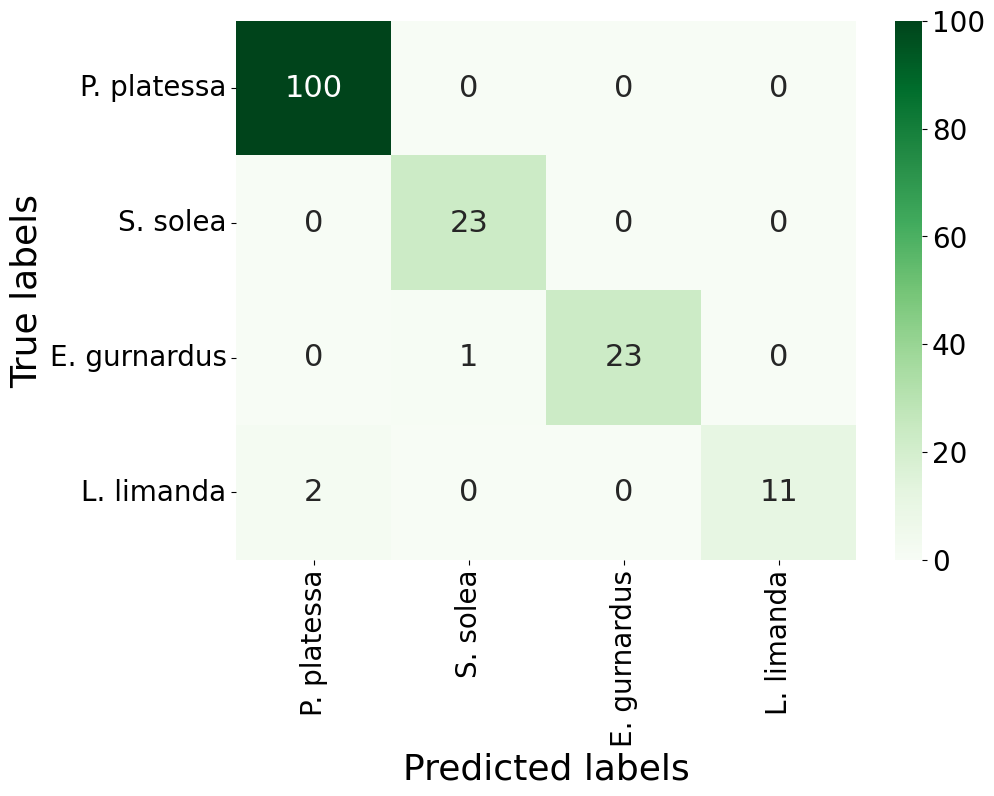

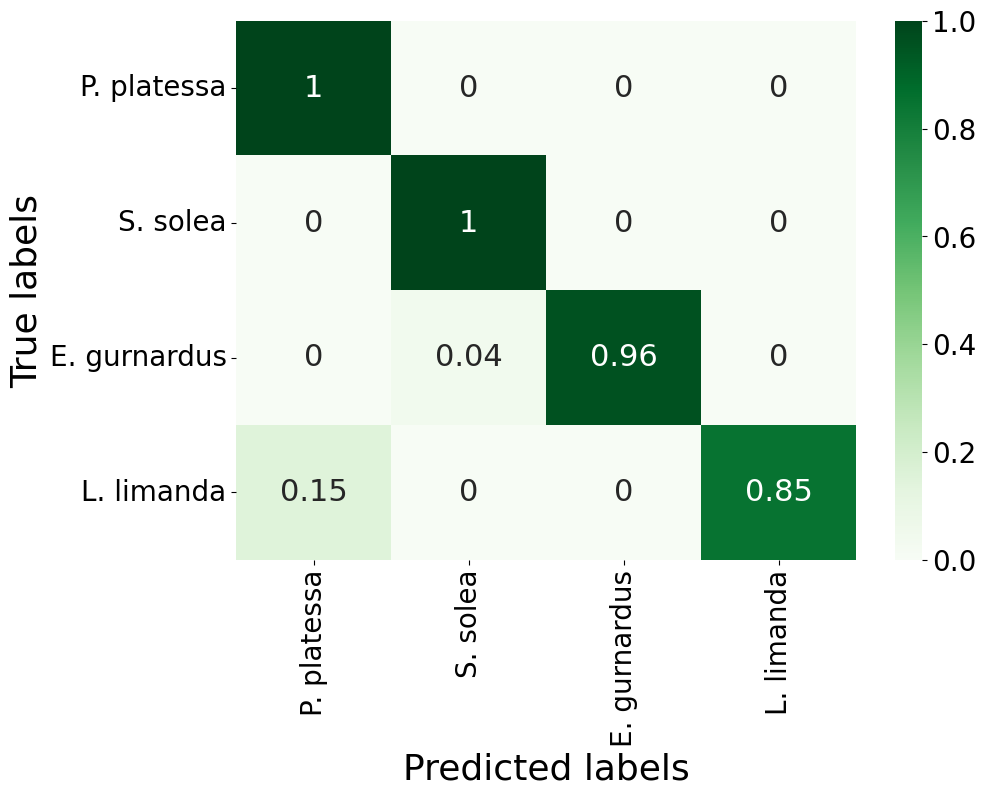

In [ ]:

print(known_classes)
best_k = 3
#Closed set test
classifier_3nn = KNeighborsClassifier(n_neighbors=best_k, metric='precomputed')
classifier_3nn.fit(train_distances, Y_train)
#closed set result
knn_preds = classifier_3nn.predict(val_distances)

print('Closed set scenario:')
print(':'*30 , 'Val', ':'*30)
closed_set_metrics(Y_val, knn_preds, known_classes, SPECIES)
print('*'*50)


#closed set result
knn_preds = classifier_3nn.predict(test_distances)

print(':'*30 , 'Test', ':'*30)
closed_set_metrics(Y_test, knn_preds, known_classes, SPECIES)
print('*'*50)

plot_conf_matrix(knn_preds, Y_test, known_classes, SPECIES, normalize=False, split=split_used)
plot_conf_matrix(knn_preds, Y_test, known_classes, SPECIES, normalize=True, split=split_used)

##OSNN algorithm

In [ ]:
#OSNN threshold
classifier = KNeighborsClassifier(n_neighbors=(Y_train.shape[0]), metric='precomputed')
classifier.fit(train_distances, Y_train)
dist, indexes = classifier.kneighbors(val_distances)

#ratio_threshold_mc = find_threshold(dist, indexes, Y_train, Y_val)
#print('average-based multiclass ratio_threshold:',ratio_threshold_mc)

#ratio_threshold_bin = find_threshold_binaryProblem(dist, indexes, Y_train, val_distances,Y_val)
ratio_threshold_bin = find_threshold_binaryF1Macro(dist, indexes, Y_train, val_distances,Y_val)

print('Binary F1_macro ratio_threshold:',ratio_threshold_bin)

Binary F1_macro ratio_threshold: 0.626


In [ ]:
#OSNN inference VALIDATION set
print('*'*60)
print('Val set')

#ratio_threshold_bin = 0.491
ratio_threshold = ratio_threshold_bin

y_pred_val, y_ratios_val = run_osnn(classifier, Y_train, val_distances, ratio_threshold)
open_set_metrics(Y_val, y_pred_val, y_ratios_val, known_classes, SPECIES)

************************************************************
Val set
Known samples accuracy: 87.647
Known samples Macro F1: 69.441
Known samples Weighted F1: 92.699
Unknown samples accuracy: 84.733
OS Binary F1-macro 84.594
OS Binary F1-weighted 87.323
OS Binary AUC_score 91.087
Global Accuracy: 86.837
F1_macro (KC + UKC): 82.955
F1_weighted (KC + UKC): 86.764
******************** PER SPECIES ********************
              precision    recall  f1-score   support

 P. platessa       0.94      0.96      0.95       203
    S. solea       0.80      0.73      0.76        48
E. gurnardus       1.00      0.90      0.95        58
  L. limanda       1.00      0.55      0.71        31
     Unknown       0.73      0.85      0.78       131

    accuracy                           0.87       471
   macro avg       0.89      0.80      0.83       471
weighted avg       0.88      0.87      0.87       471



************************************************************
Test set
Known samples accuracy: 90.625
Known samples Macro F1: 70.804
Known samples Weighted F1: 94.595
Unknown samples accuracy: 68.098
OS Binary F1-macro 79.025
OS Binary F1-weighted 79.004
OS Binary AUC_score 91.108
Global Accuracy: 79.257
F1_macro (KC + UKC): 76.252
F1_weighted (KC + UKC): 80.608
******************** PER SPECIES ********************
              precision    recall  f1-score   support

 P. platessa       0.89      0.99      0.94       100
    S. solea       1.00      0.74      0.85        23
E. gurnardus       0.34      0.88      0.49        24
  L. limanda       1.00      0.62      0.76        13
     Unknown       0.88      0.68      0.77       163

    accuracy                           0.79       323
   macro avg       0.82      0.78      0.76       323
weighted avg       0.86      0.79      0.81       323



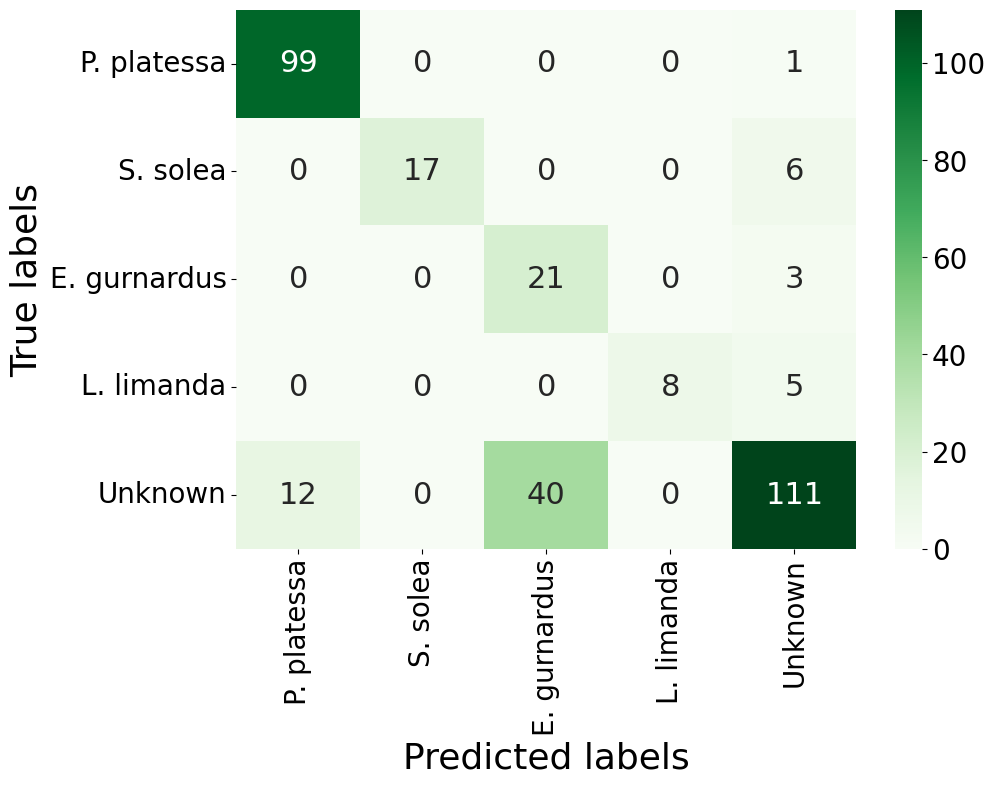

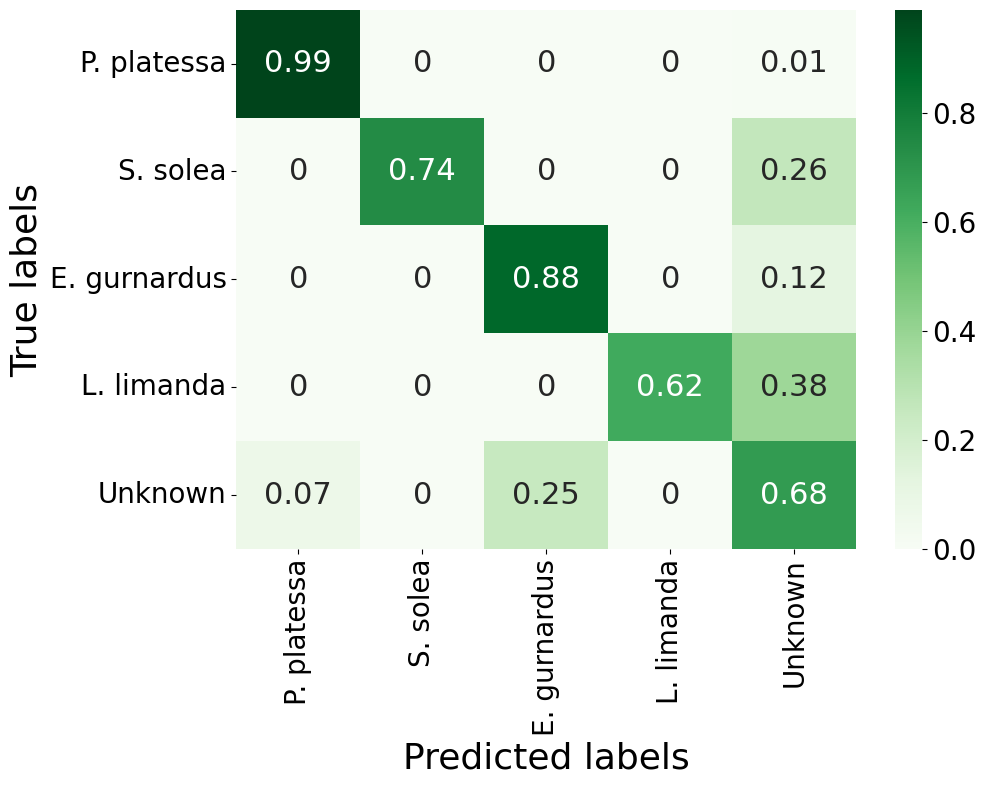

In [ ]:
#OSNN inference TEST set
#ratio_threshold_bin = 0.1
ratio_threshold = ratio_threshold_bin
print('*'*60)
print('Test set')

y_pred_test, y_ratios_test = run_osnn(classifier, Y_train, test_distances, ratio_threshold)

open_set_metrics(Y_test, y_pred_test, y_ratios_test, known_classes, SPECIES)


plot_conf_matrix(y_pred_test, Y_test, known_classes, SPECIES, open_set = True, normalize=False, split= split_used)
plot_conf_matrix(y_pred_test, Y_test, known_classes, SPECIES, open_set = True, normalize=True, split= split_used)

In [ ]:
#print img missclassified
print('*'*15, 'Closed-set', '*'*15)
#check_false_positives_image_path(Y_test, knn_preds, known_classes, SPECIES, images_test)

print('\n')
print('*'*15, 'Open-set', '*'*15)
species_indexes = np.concatenate((known_classes.copy(),[999]))
check_false_positives_image_path(Y_test, y_pred_test, species_indexes, SPECIES, images_test)